=== COMPARACIÓN DE DETECCIÓN DE MATRÍCULAS ===
Archivo 1: ../CSVs/deteccion_de_matricula_easyocr.csv (EasyOCR)
Archivo 2: ../CSVs/deteccion_de_matricula_tesseract.csv (Tesseract)
Matrícula real de referencia: ET3633P
Mínimo caracteres coincidentes: 3

Columnas en CSV1: ['fotograma', 'tipo_objeto', 'confianza_deteccion', 'x1', 'y1', 'x2', 'y2', 'matrícula_detectada', 'x1_matrícula', 'y1_matrícula', 'x2_matrícula', 'y2_matrícula', 'texto_matricula_ocr', 'tiempo_inferencia_yolo', 'tiempo_inferencia_easyocr']
Columnas en CSV2: ['fotograma', 'tipo_objeto', 'confianza_deteccion', 'x1', 'y1', 'x2', 'y2', 'matrícula_detectada', 'x1_matrícula', 'y1_matrícula', 'x2_matrícula', 'y2_matrícula', 'texto_matricula_ocr', 'tiempo_inferencia_yolo', 'tiempo_inferencia_tesseract']

Detecciones con matrícula en EasyOCR: 115
Detecciones con matrícula en Tesseract: 191



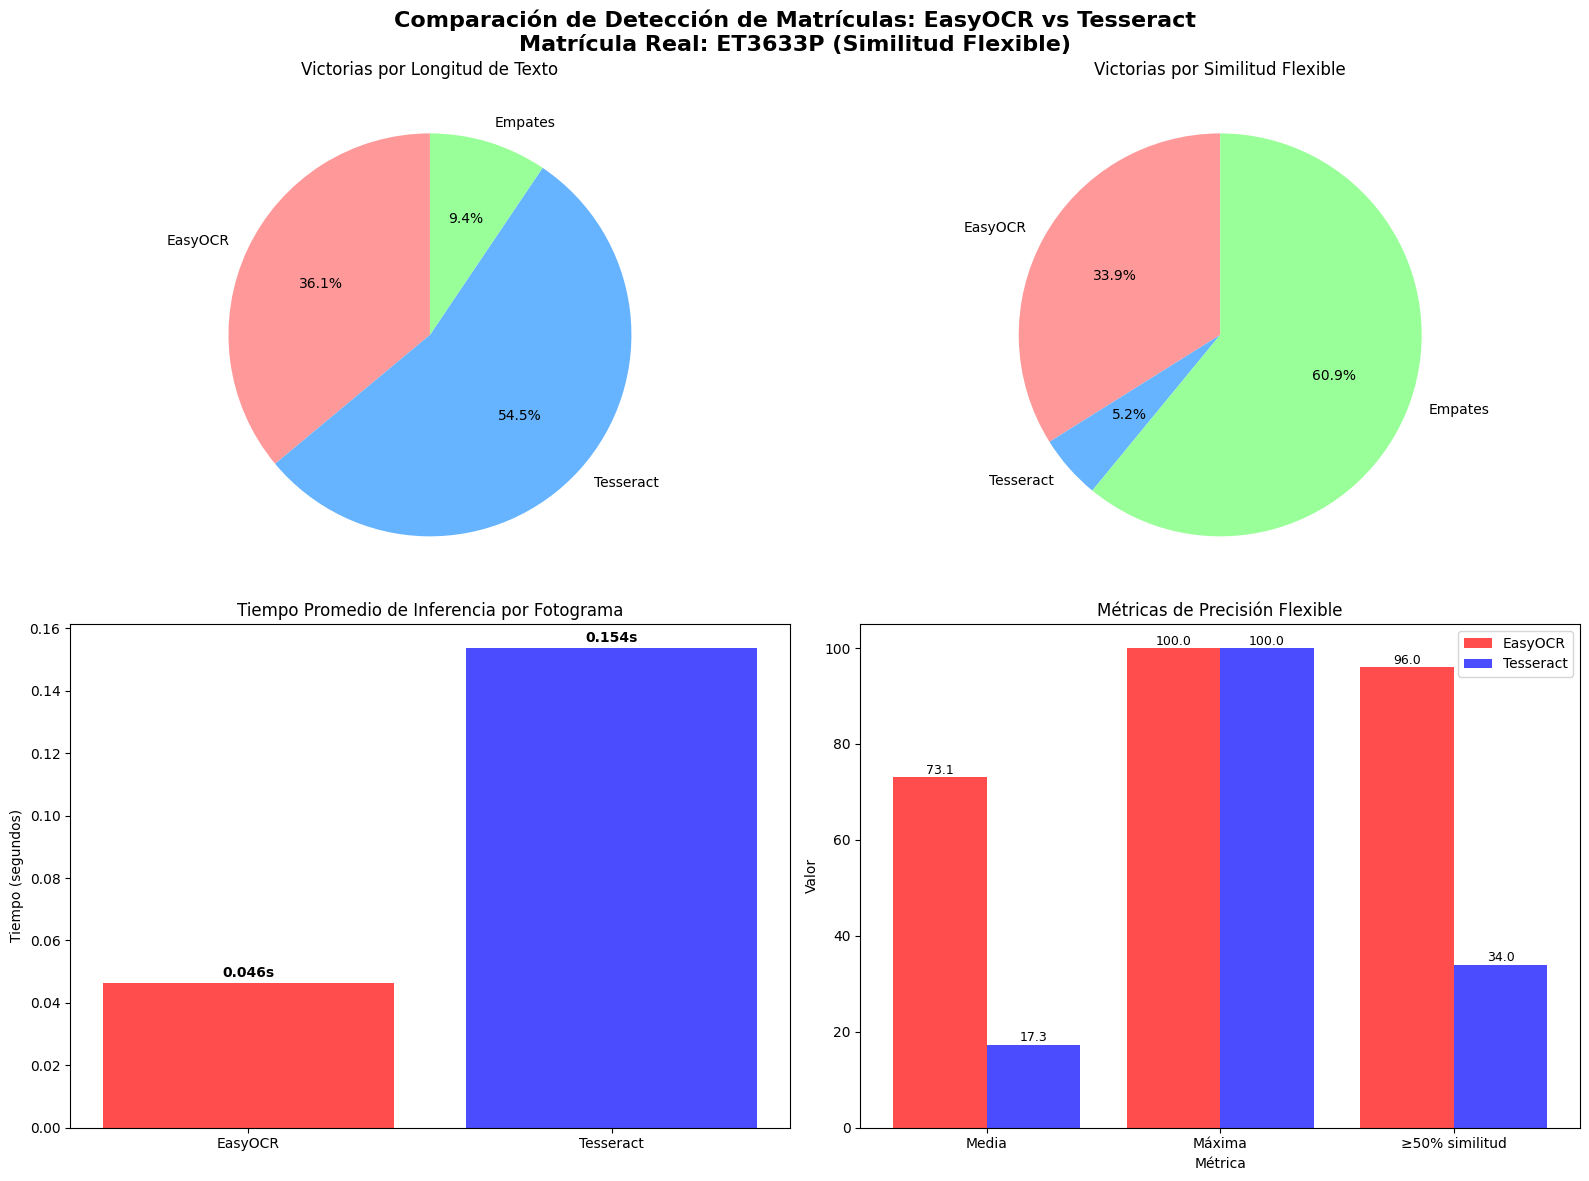

=== ESTADÍSTICAS GENERALES ===
Fotogramas con detecciones: 233

=== COMPARACIÓN POR LONGITUD ===
Fotogramas donde EasyOCR es mejor: 84 (36.1%)
Fotogramas donde Tesseract es mejor: 127 (54.5%)
Empates: 22 (9.4%)

=== COMPARACIÓN POR PRECISIÓN FLEXIBLE (vs ET3633P) ===
Fotogramas donde EasyOCR es más preciso: 79 (33.9%)
Fotogramas donde Tesseract es más preciso: 12 (5.2%)
Empates: 142 (60.9%)

=== DETECCIONES CON BUENA SIMILITUD (≥50%) ===
EasyOCR: 96 detecciones (83.5%)
Tesseract: 34 detecciones (17.8%)

=== TIEMPOS DE INFERENCIA ===
EasyOCR:
  - Tiempo promedio por fotograma: 0.046 segundos
  - Tiempo total: 5.32 segundos
Tesseract:
  - Tiempo promedio por fotograma: 0.154 segundos
  - Tiempo total: 29.36 segundos

=== RESULTADOS FINALES ===
GANADOR POR LONGITUD: Tesseract
GANADOR POR PRECISIÓN FLEXIBLE: EasyOCR
GANADOR POR VELOCIDAD: EasyOCR

GANADOR GENERAL: EasyOCR
Análisis completado. Gráficas guardadas en 'comparacion_matriculas_flexible.png'


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo para las gráficas
plt.style.use('default')
sns.set_palette("husl")

# Matrícula real para comparación
MATRICULA_REAL = "ET3633P"

def limpiar_texto_matricula(texto):
    """
    Limpia el texto de la matrícula eliminando espacios y caracteres no alfanuméricos
    """
    if pd.isna(texto):
        return ""
    return ''.join(c for c in str(texto).upper() if c.isalnum())

def caracteres_similares(c1, c2):
    """
    Determina si dos caracteres son similares (confusiones comunes en OCR)
    """
    # Si son iguales, son similares
    if c1 == c2:
        return True
    
    # Lista de caracteres comúnmente confundidos
    grupos_similitud = [
        {'0', 'O', 'D', 'Q'},  # Ceros y letras redondeadas
        {'1', 'I', 'L', '7'},  # Unos y líneas verticales
        {'2', 'Z'},            # Dos y Zeta
        {'5', 'S'},            # Cinco y Ese
        {'8', 'B'},            # Ocho y Be
        {'6', 'G'},            # Seis y Ge
        {'0', '8'},            # Cero y Ocho
        {'3', '8'},            # Tres y Ocho
        {'4', 'A'},            # Cuatro y A
        {'9', 'P'},            # Nueve y Pe
        {'E', 'F'},            # E y F
        {'C', 'G'},            # C y G
        {'U', 'V'},            # U y V
        {'M', 'N'},            # M y N
    ]
    
    # Verificar si los caracteres están en el mismo grupo de similitud
    for grupo in grupos_similitud:
        if c1 in grupo and c2 in grupo:
            return True
    
    return False

def calcular_similitud_flexible(texto_detectado, texto_real, min_caracteres=2):
    """
    Calcula la similitud flexible entre la matrícula detectada y la real
    Considera caracteres similares y busca coincidencias en cualquier posición
    """
    if not texto_detectado or len(texto_detectado) < min_caracteres:
        return 0
    
    texto_detectado = texto_detectado.upper()
    texto_real = texto_real.upper()
    
    # Método 1: Coincidencias exactas en cualquier posición
    coincidencias_exactas = sum(1 for c in texto_detectado if c in texto_real)
    
    # Método 2: Coincidencias con caracteres similares
    coincidencias_similares = 0
    caracteres_reales_usados = set()
    
    for c_detectado in texto_detectado:
        for c_real in texto_real:
            if c_real not in caracteres_reales_usados and caracteres_similares(c_detectado, c_real):
                coincidencias_similares += 1
                caracteres_reales_usados.add(c_real)
                break
    
    # Método 3: Coincidencias por subcadenas (buscar grupos de caracteres)
    max_subcadena = 0
    for i in range(len(texto_detectado)):
        for j in range(i + min_caracteres, len(texto_detectado) + 1):
            subcadena = texto_detectado[i:j]
            if subcadena in texto_real:
                max_subcadena = max(max_subcadena, len(subcadena))
    
    # Ponderar los diferentes métodos
    peso_exactas = 0.4
    peso_similares = 0.4
    peso_subcadenas = 0.2
    
    puntuacion_exactas = (coincidencias_exactas / len(texto_real)) * 100
    puntuacion_similares = (coincidencias_similares / len(texto_real)) * 100
    puntuacion_subcadenas = (max_subcadena / len(texto_real)) * 100
    
    similitud_total = (puntuacion_exactas * peso_exactas + 
                      puntuacion_similares * peso_similares + 
                      puntuacion_subcadenas * peso_subcadenas)
    
    # Bonus si tiene al menos min_caracteres coincidentes
    if coincidencias_exactas >= min_caracteres or coincidencias_similares >= min_caracteres:
        similitud_total = min(100, similitud_total + 20)  # Bonus del 20%
    
    return min(100, similitud_total)

def obtener_tiempo_inferencia(fila, modelo):
    """
    Obtiene el tiempo de inferencia según el modelo
    """
    if modelo == "EasyOCR":
        # Para EasyOCR usamos la columna de tiempo_inferencia_easyocr
        if 'tiempo_inferencia_easyocr' in fila.index:
            return fila['tiempo_inferencia_easyocr']
        elif 'tiempo_inferencia_yolo' in fila.index and 'tiempo_inferencia_tesseract' in fila.index:
            return fila['tiempo_inferencia_yolo'] + fila['tiempo_inferencia_tesseract']
        else:
            return 0
    elif modelo == "Tesseract":
        # Para Tesseract usamos la columna de tiempo_inferencia_tesseract
        if 'tiempo_inferencia_tesseract' in fila.index:
            return fila['tiempo_inferencia_tesseract']
        elif 'tiempo_inferencia_yolo' in fila.index and 'tiempo_inferencia_easyocr' in fila.index:
            return fila['tiempo_inferencia_yolo'] + fila['tiempo_inferencia_easyocr']
        else:
            return 0
    return 0

def comparar_y_graficar_matriculas(csv1, csv2, nombre1="EasyOCR", nombre2="Tesseract", min_caracteres_coincidentes=3):
    """
    Compara dos archivos CSV de detecciones de matrículas y genera gráficas comparativas
    """
    try:
        # Leer los archivos CSV
        df1 = pd.read_csv(csv1, delimiter=';')
        df2 = pd.read_csv(csv2, delimiter=';')
        
        print(f"=== COMPARACIÓN DE DETECCIÓN DE MATRÍCULAS ===")
        print(f"Archivo 1: {csv1} ({nombre1})")
        print(f"Archivo 2: {csv2} ({nombre2})")
        print(f"Matrícula real de referencia: {MATRICULA_REAL}")
        print(f"Mínimo caracteres coincidentes: {min_caracteres_coincidentes}")
        print()
        
        # Mostrar columnas disponibles para debugging
        print("Columnas en CSV1:", df1.columns.tolist())
        print("Columnas en CSV2:", df2.columns.tolist())
        print()
        
        # Filtrar solo las detecciones donde se detectó matrícula
        df1_matriculas = df1[
            (df1['matrícula_detectada'].str.upper() == 'SÍ') | 
            (df1['matrícula_detectada'].str.upper() == 'SI') |
            (df1['matrícula_detectada'] == True)
        ].copy()
        
        df2_matriculas = df2[
            (df2['matrícula_detectada'].str.upper() == 'SÍ') | 
            (df2['matrícula_detectada'].str.upper() == 'SI') |
            (df2['matrícula_detectada'] == True)
        ].copy()
        
        print(f"Detecciones con matrícula en {nombre1}: {len(df1_matriculas)}")
        print(f"Detecciones con matrícula en {nombre2}: {len(df2_matriculas)}")
        print()
        
        # Procesar texto de matrículas
        df1_matriculas['texto_limpio'] = df1_matriculas['texto_matricula_ocr'].apply(limpiar_texto_matricula)
        df2_matriculas['texto_limpio'] = df2_matriculas['texto_matricula_ocr'].apply(limpiar_texto_matricula)
        
        # Calcular longitud de texto detectado
        df1_matriculas['longitud_texto'] = df1_matriculas['texto_limpio'].str.len()
        df2_matriculas['longitud_texto'] = df2_matriculas['texto_limpio'].str.len()
        
        # Calcular similitud flexible con matrícula real
        df1_matriculas['similitud'] = df1_matriculas['texto_limpio'].apply(
            lambda x: calcular_similitud_flexible(x, MATRICULA_REAL, min_caracteres_coincidentes)
        )
        df2_matriculas['similitud'] = df2_matriculas['texto_limpio'].apply(
            lambda x: calcular_similitud_flexible(x, MATRICULA_REAL, min_caracteres_coincidentes)
        )
        
        # Contar detecciones con buen nivel de coincidencia
        buen_match_csv1 = len(df1_matriculas[df1_matriculas['similitud'] >= 50])
        buen_match_csv2 = len(df2_matriculas[df2_matriculas['similitud'] >= 50])
        
        # Calcular tiempos de inferencia específicos para cada modelo
        df1_matriculas['tiempo_inferencia'] = df1_matriculas.apply(
            lambda x: obtener_tiempo_inferencia(x, nombre1), axis=1
        )
        df2_matriculas['tiempo_inferencia'] = df2_matriculas.apply(
            lambda x: obtener_tiempo_inferencia(x, nombre2), axis=1
        )
        
        # Estadísticas de tiempo
        tiempo_total_csv1 = df1_matriculas['tiempo_inferencia'].sum()
        tiempo_total_csv2 = df2_matriculas['tiempo_inferencia'].sum()
        
        tiempo_promedio_csv1 = df1_matriculas['tiempo_inferencia'].mean()
        tiempo_promedio_csv2 = df2_matriculas['tiempo_inferencia'].mean()
        
        # Estadísticas por fotograma
        estadisticas_fotograma = defaultdict(lambda: {
            'csv1_longitud': 0, 'csv2_longitud': 0, 
            'csv1_texto': '', 'csv2_texto': '',
            'csv1_similitud': 0, 'csv2_similitud': 0
        })
        
        # Procesar CSV1
        for _, row in df1_matriculas.iterrows():
            fotograma = row['fotograma']
            texto = row['texto_limpio']
            estadisticas_fotograma[fotograma]['csv1_longitud'] = len(texto)
            estadisticas_fotograma[fotograma]['csv1_texto'] = texto
            estadisticas_fotograma[fotograma]['csv1_similitud'] = row['similitud']
        
        # Procesar CSV2
        for _, row in df2_matriculas.iterrows():
            fotograma = row['fotograma']
            texto = row['texto_limpio']
            estadisticas_fotograma[fotograma]['csv2_longitud'] = len(texto)
            estadisticas_fotograma[fotograma]['csv2_texto'] = texto
            estadisticas_fotograma[fotograma]['csv2_similitud'] = row['similitud']
        
        # Comparar por fotograma
        resultados_comparacion = []
        fotogramas_comunes = 0
        csv1_mejor_longitud = 0
        csv2_mejor_longitud = 0
        csv1_mejor_similitud = 0
        csv2_mejor_similitud = 0
        empates_longitud = 0
        empates_similitud = 0
        
        for fotograma, datos in estadisticas_fotograma.items():
            if datos['csv1_longitud'] > 0 or datos['csv2_longitud'] > 0:
                fotogramas_comunes += 1
                
                # Comparación por longitud
                if datos['csv1_longitud'] > datos['csv2_longitud']:
                    csv1_mejor_longitud += 1
                elif datos['csv2_longitud'] > datos['csv1_longitud']:
                    csv2_mejor_longitud += 1
                else:
                    empates_longitud += 1
                
                # Comparación por similitud
                if datos['csv1_similitud'] > datos['csv2_similitud']:
                    csv1_mejor_similitud += 1
                elif datos['csv2_similitud'] > datos['csv1_similitud']:
                    csv2_mejor_similitud += 1
                else:
                    empates_similitud += 1
                
                resultados_comparacion.append({
                    'fotograma': fotograma,
                    f'{nombre1}_longitud': datos['csv1_longitud'],
                    f'{nombre2}_longitud': datos['csv2_longitud'],
                    f'{nombre1}_texto': datos['csv1_texto'],
                    f'{nombre2}_texto': datos['csv2_texto'],
                    f'{nombre1}_similitud': datos['csv1_similitud'],
                    f'{nombre2}_similitud': datos['csv2_similitud'],
                    'ganador_longitud': nombre1 if datos['csv1_longitud'] > datos['csv2_longitud'] else 
                                      nombre2 if datos['csv2_longitud'] > datos['csv1_longitud'] else 'Empate',
                    'ganador_similitud': nombre1 if datos['csv1_similitud'] > datos['csv2_similitud'] else 
                                       nombre2 if datos['csv2_similitud'] > datos['csv1_similitud'] else 'Empate'
                })
        
        # Crear DataFrame de resultados
        df_resultados = pd.DataFrame(resultados_comparacion)
        
        # ========== CREACIÓN DE GRÁFICAS ==========
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f'Comparación de Detección de Matrículas: {nombre1} vs {nombre2}\nMatrícula Real: {MATRICULA_REAL} (Similitud Flexible)', 
                    fontsize=16, fontweight='bold')
        
        # Gráfica 1: Comparación de victorias por longitud
        labels_longitud = [nombre1, nombre2, 'Empates']
        sizes_longitud = [csv1_mejor_longitud, csv2_mejor_longitud, empates_longitud]
        colors = ['#ff9999', '#66b3ff', '#99ff99']
        
        axes[0, 0].pie(sizes_longitud, labels=labels_longitud, autopct='%1.1f%%', 
                      colors=colors, startangle=90)
        axes[0, 0].set_title('Victorias por Longitud de Texto')
        
        # Gráfica 2: Comparación de victorias por similitud
        labels_similitud = [nombre1, nombre2, 'Empates']
        sizes_similitud = [csv1_mejor_similitud, csv2_mejor_similitud, empates_similitud]
        
        axes[0, 1].pie(sizes_similitud, labels=labels_similitud, autopct='%1.1f%%', 
                      colors=colors, startangle=90)
        axes[0, 1].set_title('Victorias por Similitud Flexible')
        
        # Gráfica 3: Comparación de tiempos de inferencia promedio
        tiempos_modelos = [tiempo_promedio_csv1, tiempo_promedio_csv2]
        modelos = [nombre1, nombre2]
        
        bars = axes[1, 0].bar(modelos, tiempos_modelos, color=['red', 'blue'], alpha=0.7)
        axes[1, 0].set_title('Tiempo Promedio de Inferencia por Fotograma')
        axes[1, 0].set_ylabel('Tiempo (segundos)')
        
        # Añadir valores en las barras
        for bar, tiempo in zip(bars, tiempos_modelos):
            axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                           f'{tiempo:.3f}s', ha='center', va='bottom', fontweight='bold')
        
        # Gráfica 4: Comparación de métricas de precisión
        metricas_similitud = ['Media', 'Máxima', f'≥50% similitud']
        valores_csv1_sim = [
            df1_matriculas['similitud'].mean(),
            df1_matriculas['similitud'].max(),
            buen_match_csv1
        ]
        valores_csv2_sim = [
            df2_matriculas['similitud'].mean(),
            df2_matriculas['similitud'].max(),
            buen_match_csv2
        ]
        
        x_metricas = np.arange(len(metricas_similitud))
        axes[1, 1].bar(x_metricas - 0.2, valores_csv1_sim, 0.4, label=nombre1, alpha=0.7, color='red')
        axes[1, 1].bar(x_metricas + 0.2, valores_csv2_sim, 0.4, label=nombre2, alpha=0.7, color='blue')
        axes[1, 1].set_title('Métricas de Precisión Flexible')
        axes[1, 1].set_xlabel('Métrica')
        axes[1, 1].set_ylabel('Valor')
        axes[1, 1].set_xticks(x_metricas)
        axes[1, 1].set_xticklabels(metricas_similitud)
        axes[1, 1].legend()
        
        # Añadir valores en las barras de precisión
        for i, v in enumerate(valores_csv1_sim):
            axes[1, 1].text(i - 0.2, v + 0.1, f'{v:.1f}', ha='center', va='bottom', fontsize=9)
        for i, v in enumerate(valores_csv2_sim):
            axes[1, 1].text(i + 0.2, v + 0.1, f'{v:.1f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.savefig('comparacion_matriculas_flexible.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # ========== ESTADÍSTICAS DETALLADAS ==========
        print("=== ESTADÍSTICAS GENERALES ===")
        print(f"Fotogramas con detecciones: {fotogramas_comunes}")
        print()
        
        print("=== COMPARACIÓN POR LONGITUD ===")
        print(f"Fotogramas donde {nombre1} es mejor: {csv1_mejor_longitud} ({csv1_mejor_longitud/fotogramas_comunes*100:.1f}%)")
        print(f"Fotogramas donde {nombre2} es mejor: {csv2_mejor_longitud} ({csv2_mejor_longitud/fotogramas_comunes*100:.1f}%)")
        print(f"Empates: {empates_longitud} ({empates_longitud/fotogramas_comunes*100:.1f}%)")
        print()
        
        print(f"=== COMPARACIÓN POR PRECISIÓN FLEXIBLE (vs {MATRICULA_REAL}) ===")
        print(f"Fotogramas donde {nombre1} es más preciso: {csv1_mejor_similitud} ({csv1_mejor_similitud/fotogramas_comunes*100:.1f}%)")
        print(f"Fotogramas donde {nombre2} es más preciso: {csv2_mejor_similitud} ({csv2_mejor_similitud/fotogramas_comunes*100:.1f}%)")
        print(f"Empates: {empates_similitud} ({empates_similitud/fotogramas_comunes*100:.1f}%)")
        print()
        
        print("=== DETECCIONES CON BUENA SIMILITUD (≥50%) ===")
        print(f"{nombre1}: {buen_match_csv1} detecciones ({buen_match_csv1/len(df1_matriculas)*100:.1f}%)")
        print(f"{nombre2}: {buen_match_csv2} detecciones ({buen_match_csv2/len(df2_matriculas)*100:.1f}%)")
        print()
        
        print("=== TIEMPOS DE INFERENCIA ===")
        print(f"{nombre1}:")
        print(f"  - Tiempo promedio por fotograma: {tiempo_promedio_csv1:.3f} segundos")
        print(f"  - Tiempo total: {tiempo_total_csv1:.2f} segundos")
        print(f"{nombre2}:")
        print(f"  - Tiempo promedio por fotograma: {tiempo_promedio_csv2:.3f} segundos")
        print(f"  - Tiempo total: {tiempo_total_csv2:.2f} segundos")
        print()
        
        # Determinar ganadores
        ganador_longitud = nombre1 if csv1_mejor_longitud > csv2_mejor_longitud else nombre2 if csv2_mejor_longitud > csv1_mejor_longitud else "Empate"
        ganador_similitud = nombre1 if csv1_mejor_similitud > csv2_mejor_similitud else nombre2 if csv2_mejor_similitud > csv1_mejor_similitud else "Empate"
        ganador_tiempo = nombre1 if tiempo_promedio_csv1 < tiempo_promedio_csv2 else nombre2
        
        print("=== RESULTADOS FINALES ===")
        print(f"GANADOR POR LONGITUD: {ganador_longitud}")
        print(f"GANADOR POR PRECISIÓN FLEXIBLE: {ganador_similitud}")
        print(f"GANADOR POR VELOCIDAD: {ganador_tiempo}")
        print()
        
        # Ganador general (ponderando precisión y velocidad)
        if fotogramas_comunes > 0:
            puntuacion_csv1 = (csv1_mejor_similitud * 0.7) + ((1/max(tiempo_promedio_csv1, 0.001)) * 0.3 * 100)
            puntuacion_csv2 = (csv2_mejor_similitud * 0.7) + ((1/max(tiempo_promedio_csv2, 0.001)) * 0.3 * 100)
        else:
            puntuacion_csv1 = puntuacion_csv2 = 0
        
        if puntuacion_csv1 > puntuacion_csv2:
            ganador_general = nombre1
        elif puntuacion_csv2 > puntuacion_csv1:
            ganador_general = nombre2
        else:
            ganador_general = "Empate"
        
        print(f"GANADOR GENERAL: {ganador_general}")
        
        return df_resultados, ganador_general
        
    except Exception as e:
        print(f"Error al procesar los archivos: {e}")
        import traceback
        traceback.print_exc()
        return None, None

if __name__ == "__main__":
    # Configuración
    archivo_csv1 = "../CSVs/deteccion_de_matricula_easyocr.csv"
    archivo_csv2 = "../CSVs/deteccion_de_matricula_tesseract.csv"
    nombre_csv1 = "EasyOCR"
    nombre_csv2 = "Tesseract"
    
    # Ejecutar comparación con similitud flexible
    resultados, ganador = comparar_y_graficar_matriculas(
        archivo_csv1, archivo_csv2, nombre_csv1, nombre_csv2, min_caracteres_coincidentes=3
    )
    
    if resultados is not None:
        print("Análisis completado. Gráficas guardadas en 'comparacion_matriculas_flexible.png'")